In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.special import hyp2f1

from classy import Class
from multipoles import LegendreMultipoleExtractor
from covariances_pk_xi import PkXiCovariance

%matplotlib inline
%load_ext autoreload
%autoreload 2

/tmp/ipykernel_2178216/2809590261.py:25: RuntimeWarning: invalid value encountered in divide
  corr = (cov/np.outer(std,std)).clip(-1,1)


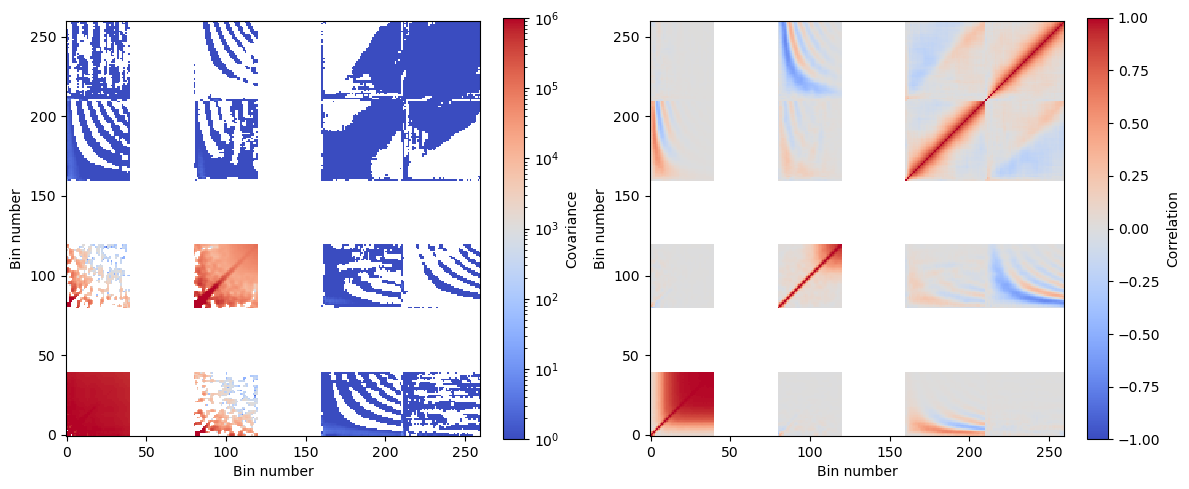

In [7]:
# Path to the data.
db  = '/pscratch/sd/m/mmaus/C3PO/data/spec_z_dat/pkxi_DR1_uncorrected/'
# Since it's helpful to have the k values, load
# them from the P(k) file.
fn  = 'pkxi_dat/Pk_LRG2_ell02.txt'
pkd = np.loadtxt(db+fn)
xid = np.loadtxt(db+'pkxi_dat/Xipost_LRG2_ell02.txt')

konh = pkd[:,0]

# Whether or not we're going to rotate the window in order to 
# mitigate sensitivity to high k after applying theta cut
rotate_window = True
if rotate_window:
    fn  = 'pkxi_cov/PkXi_joint_LRG2_ell02_cov_rotated_hack.txt' # Cutsky rotated
else:
    fn  = 'pkxi_cov/PkXi_joint_LRG2_ell02_cov.txt' # Cutsky

# Load the covariance matrix.
cov = np.loadtxt(db+fn)


# and compute the correlation matrix.
std  = np.sqrt(np.diag(cov))
corr = (cov/np.outer(std,std)).clip(-1,1)
Nd   = corr.shape[0]
# Work out the boundaries of the sub-blocks.
Np0  = pkd.shape[0]       # Number of P_0 k bins = last index.
Np2  = pkd.shape[0] + Np0 # Last index of P_2 k bins.
Nx0  = xid.shape[0] + Np2           # Last index of xi_0 r bins
Nx2  = xid.shape[0] + Nx0           # Last index of xi_2 r bins

# Get an overview.
fig,ax = plt.subplots(1,2,figsize=(12,12))
#
im1 = ax[0].imshow(cov ,cmap='coolwarm',origin='lower',
                   interpolation='nearest',vmin=1,vmax=1e6,norm='log')
fig.colorbar(im1,label='Covariance',ax=ax[0],fraction=0.046)
#
im2 = ax[1].imshow(corr,cmap='coolwarm',origin='lower',
                   interpolation='nearest',vmin=-1, vmax=1)
fig.colorbar(im2,label='Correlation',ax=ax[1],fraction=0.046)
#
for i in range(ax.size):
    ax[i].set_xlabel('Bin number')
    ax[i].set_ylabel('Bin number')
#
fig.tight_layout()

In [8]:
# We are going to need the linear matter power spectrum.
# We will use CLASS to compute it.

def D_of_a(a,OmegaM=1):
    # From Stephen Chen
    return a * hyp2f1(1./3,1,11./6,-a**3/OmegaM*(1-OmegaM)) / hyp2f1(1./3,1,11./6,-1/OmegaM*(1-OmegaM))

def f_of_a(a, OmegaM=1):
    # From Stephen Chen
    Da = D_of_a(a,OmegaM=OmegaM)
    ret = Da/a - a*(6*a**2 * (1 - OmegaM) * hyp2f1(4./3, 2, 17./6, -a**3 *  (1 - OmegaM)/OmegaM))/(11*OmegaM)/hyp2f1(1./3,1,11./6,-1/OmegaM*(1-OmegaM))
    return a * ret / Da

z = 0.8
pkparams = {
    'output': 'mPk',
    'P_k_max_h/Mpc': 20.,
    'z_pk': '0.0,10',
    'A_s': 2.1e-9,
    'n_s': 0.9649,
    'h': 70 / 100.,
    'N_ur': 2.033,
    'N_ncdm': 1,
    'm_ncdm': 0.06,
    'tau_reio': 0.0568,
    'omega_b': 0.022,
    'omega_cdm': 0.12}

OmegaM = (pkparams['omega_cdm'] + pkparams['omega_b'] + 0.0106 *pkparams['m_ncdm']) / pkparams['h'] ** 2

pkclass = Class()
pkclass.set(pkparams)
pkclass.compute()

# Calculate growth rate
fnu = pkclass.Omega_nu / pkclass.Omega_m()
f = f_of_a(1 / (1. + z), OmegaM=OmegaM) * (1 - 0.6 * fnu)

# Calculate and renormalize power spectrum
plin = np.array([pkclass.pk_cb(k * pkparams['h'], z) * pkparams['h'] ** 3 for k in konh])

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_2178216/1274547572.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(konh, konh*P_cross_of_mu(mu), label=f'$\mu$={mu:.2f}')
/tmp/ipykernel_2178216/1274547572.py:22: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel('$k\,P_{cross}(k, \mu)$')
/tmp/ipykernel_2178216/1274547572.py:23: SyntaxWarning: invalid escape sequence '\,'
  plt.title('$k\,P_{cross}(k, \mu)$ vs $k$ for different $\mu$')
/tmp/ipykernel_2178216/1274547572.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return D_of_mu(mu) * np.trapz(sigmasq_integrand, konh)


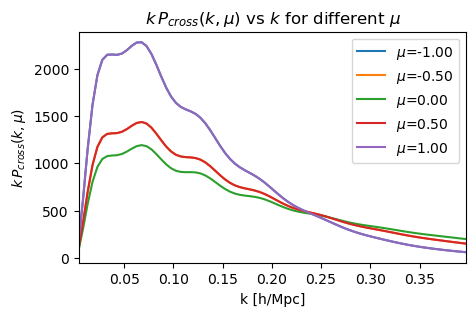

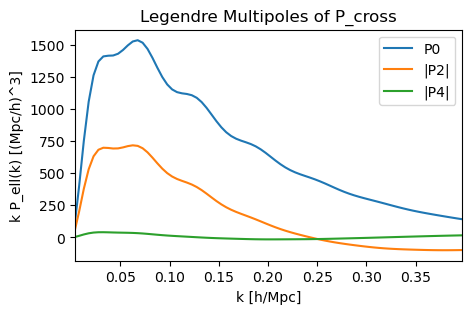

In [9]:
# Now we approximate the P_cross(k, mu) as in the notes. We use a Gaussian smoothing kernel with a width of 15 Mpc/h.

def D_of_mu(mu):
    return 1 + (1+f)**2 * mu**2

def W(k, R_width=15):
    # A fourier-space gaussian smoothing kernel with a real-space width of 15 Mpc/h
    return np.exp(-0.5 * (k * R_width)**2)

def sigma_squared(mu):
    sigmasq_integrand = plin* W(konh)**2 / (6*np.pi**2)  
    return D_of_mu(mu) * np.trapz(sigmasq_integrand, konh)

def P_cross_of_mu(mu, b=1.95):
    return (b+f*mu**2)**2 * plin * np.exp(-konh**2 * sigma_squared(mu) / 2)

plt.figure(figsize=(5, 3))
for i, mu in enumerate(np.linspace(-1, 1, 5)):
    plt.plot(konh, konh*P_cross_of_mu(mu), label=f'$\mu$={mu:.2f}')

plt.xlabel('k [h/Mpc]')
plt.ylabel('$k\,P_{cross}(k, \mu)$')
plt.title('$k\,P_{cross}(k, \mu)$ vs $k$ for different $\mu$')
plt.xlim([konh[0],konh[-1]])
#plt.ylim([-500,500])

plt.legend()
plt.show()

# Compute multipoles of P_cross using Gauss-Legendre quadrature
extractor = LegendreMultipoleExtractor(ngauss=8)
Pcross_ells = extractor.project(P_cross_of_mu, ells=(0, 2, 4))

P0, P2, P4 = Pcross_ells[0], Pcross_ells[2], Pcross_ells[4]

plt.figure(figsize=(5, 3))
plt.plot(konh, konh*P0, label='P0')
plt.plot(konh, konh*P2, label='|P2|')
plt.plot(konh, konh*P4, label='|P4|')
plt.xlabel('k [h/Mpc]')
plt.ylabel('k P_ell(k) [(Mpc/h)^3]')
plt.title('Legendre Multipoles of P_cross')
#plt.ylim([-500,500])
plt.xlim([konh[0],konh[-1]])
plt.legend()


In [10]:
# Use the Pk–Xi covariance class to compute the disconnected block
V = 2.87e9  # (Mpc/h)^3
poles = [0, 2, 4]

# Initialize the covariance builder
cov_builder = PkXiCovariance(k=konh, r=xid[:,0], V=V, poles_Pk=poles, poles_Xi=poles,
                             ngauss_leg_product=48, r_avg_nsamp=100)
# Provide the P_cross(k,mu) 
cov_builder.set_Pcross_from_callable(P_cross_of_mu, ells=[0,2,4], ngauss_eval=8)
# Note that we could also have provided the multipoles directly as
#cov_builder.set_Pcross_from_dict(Pcross_ells)

cov_PkXi = cov_builder.compute_covariance()  # shape (3, 3, nk, nr)
print('cov_PkXi shape:', cov_PkXi.shape)

cov_PkXi shape: (3, 3, 80, 50)


/tmp/ipykernel_2178216/1274547572.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return D_of_mu(mu) * np.trapz(sigmasq_integrand, konh)
/pscratch/sd/a/ab2368/PrePostCov/covariances_pk_xi.py:104: ComplexWarning: Casting complex values to real discards the imaginary part
  cov[i, j, :, :] = S_k[:, None] * pref[None, :]


In [11]:
if rotate_window:
    from pathlib import Path
    import lsstypes as types
    zrange = [0.6, 0.8] 

    dr_base_dir = Path('/global/cfs/cdirs/desi/users/adematti/dr1_release/dr1-fs-bao-clustering-measurements')

    fn = dr_base_dir / f'data/rotation/rotation_spectrum-poles_{"LRG"}_GCcomb_z{zrange[0]:.1f}-{zrange[1]:.1f}_thetacut0.05.h5'

    rotation = types.read(fn)

    M_matrix = rotation['M'].value() # This array has shape (240, 240). The 240 comes from 3 poles (0,2,4) times 80 k-bins between 0 and 0.4 h/Mpc in steps of 0.005 h/Mpc

    # Reshape cov_PkXi to apply the rotation matrix M_matrix
    # cov_PkXi has shape (n_Pk_poles, n_Xi_poles, nk, nr) = (2, 2, 80, 50)
    # We need to flatten the (n_Pk_poles, nk) dimensions to apply M_matrix

    n_Pk_poles, n_Xi_poles, nk, nr = cov_PkXi.shape


    # Reshape to (n_Pk_poles * nk, n_Xi_poles * nr)
    cov_PkXi_flat = cov_PkXi.transpose(0, 2, 1, 3).reshape(n_Pk_poles * nk, n_Xi_poles * nr)
    print(f"Flattened cov_PkXi shape: {cov_PkXi_flat.shape}")

    # M_matrix is (240, 240) for 3 poles × 80 k-bins
    # We only need the first 2*80=160 dimensions (for 2 poles)
    M_subset = M_matrix[:n_Pk_poles*nk, :n_Pk_poles*nk]
    print(f"M_subset shape: {M_subset.shape}")

    # Apply rotation: M @ cov_PkXi_flat
    # This rotates the Pk space while leaving Xi space unchanged
    cov_PkXi_rotated_flat = M_subset @ cov_PkXi_flat
    print(f"Rotated (flat) shape: {cov_PkXi_rotated_flat.shape}")

    # Reshape back to (n_Pk_poles, n_Xi_poles, nk, nr)
    cov_PkXi_rotated = cov_PkXi_rotated_flat.reshape(n_Pk_poles, nk, n_Xi_poles, nr).transpose(0, 2, 1, 3)
    print(f"Rotated cov_PkXi shape: {cov_PkXi_rotated.shape}")

Flattened cov_PkXi shape: (240, 150)
M_subset shape: (240, 240)
Rotated (flat) shape: (240, 150)
Rotated cov_PkXi shape: (3, 3, 80, 50)


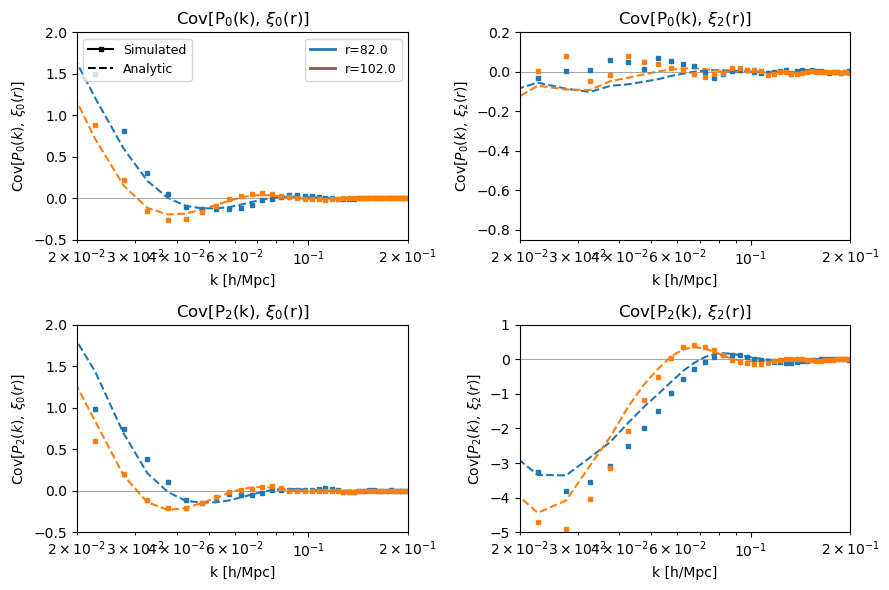

In [12]:
# Plot all four combinations of Pk and Xi poles: cross-section Cov vs k for specific r-bins
if rotate_window:
    cov_PkXi_toplot = cov_PkXi_rotated
else:
    cov_PkXi_toplot = cov_PkXi

rbins = np.array([20, 25])

# Note: The loaded cov file only has 2 poles (ell=0,2), not 3
n_poles_in_file = 2  # The file PkXi_joint_LRG2_ell02_cov only has ell=0,2

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
pole_combinations = [(0, 0), (0, 2), (2, 0), (2, 2)]

for idx, (Pkpole, Xipole) in enumerate(pole_combinations):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    Pkidx = poles.index(Pkpole)
    xiidx = poles.index(Xipole)
    i=0
    for rbin in rbins:
        cvec = cov[(Pkidx*Np0):(Pkidx+1)*Np0, rbin+Np0*n_poles_in_file+xid.shape[0]*xiidx]
        theory =  cov_PkXi_toplot[Pkidx, xiidx, :, rbin]
        
        # In a couple cases, we show the approximation that the monopole dominates.
        if (Pkpole == 0 and Xipole == 0):
            pref = 2
        elif (Pkpole == 2 and Xipole == 2):
            pref = -10
        else:
            pref = 0
        th_simp = pref * (1/V)*(cov_builder._jmean_kr(Xipole)*Pcross_ells[0][:,None]**2)[:,rbin]
        
        ax.errorbar(konh, cvec, fmt='s', color='C'+str(i), markersize=3)
        ax.plot(konh, theory, color='C'+str(i), ls='--')
        i+=1
    
    ax.set_ylabel(rf'$\mathrm{{Cov}}[P_{{{Pkpole}}}(k),\,\xi_{{{Xipole}}}(r)]$')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_xscale('log')
    ax.set_xlim([0.02, 0.2])
    ax.axhline(0, color='gray', ls='-', lw=0.5)
    ax.set_title(rf'Cov[P$_{{{Pkpole}}}$(k), $\xi_{{{Xipole}}}$(r)]')
    
    # Add legend only on the first panel
    if idx == 0:
        legend_elements = [
            Line2D([0], [0], color='C'+str(rbin), lw=2, label=f'r={cov_builder.r[rbin]:.1f}')
            for rbin in rbins
        ]
        line_legend = [
            Line2D([0], [0], color='k', marker='s', linestyle='-', markersize=3, label='Simulated'),
            Line2D([0], [0], color='k', linestyle='--', label='Analytic'),
        ]
        leg1 = ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
        leg2 = ax.legend(handles=line_legend, loc='upper left', fontsize=9)
        ax.add_artist(leg1)

axes[0,0].set_ylim([-0.5, 2])
axes[1,0].set_ylim([-0.5, 2])
axes[0,1].set_ylim([-0.85, 0.2])
axes[1,1].set_ylim([-5, 1])

fig.tight_layout()
plt.show()